In [1]:
import os
import pandas as pd
import seaborn as sns

import numpy as np
from matplotlib import pyplot as plt
import scipy

In [2]:
def heatmap(evaluation_results: pd.DataFrame, x_positions: np.ndarray, y_positions: np.ndarray, delta: float = 0.5):
    evaluation_results_list = evaluation_results.to_dict("records")
    heatmap_values = list()
    
    for i in range(len(x_positions) - 1):
        for j in range(len(y_positions) - 1):
            heatmap_values.append({
                "x": x_positions[i],
                "y": y_positions[j],
                "r": 0.0
            })

    for i in range(len(heatmap_values)):
        x_min = heatmap_values[i]["x"]
        x_max = x_min + delta

        y_min = heatmap_values[i]["y"]
        y_max = y_min + delta

        rewards = list()
        for j in range(len(evaluation_results_list)):
            x_eval = evaluation_results_list[j]["x_position"]
            y_eval = evaluation_results_list[j]["y_position"]
            r_eval = evaluation_results_list[j]["r"]

            if (x_min <= x_eval < x_max) and (y_min <= y_eval < y_max):
                rewards.append(r_eval)
                pass

        heatmap_values[i]["r"] = np.mean(rewards)
    
    heatmap_values_df = pd.DataFrame.from_dict(heatmap_values)
    heatmap_values_df["x"] = heatmap_values_df["x"] + 0.25
    heatmap_values_df["y"] = heatmap_values_df["y"] + 0.25

    heatmap = heatmap_values_df.pivot(index="y", columns=["x"], values="r")
    heatmap.sort_index(ascending=False, inplace=True)

    return heatmap

In [3]:
def merge_csvs_to_df(csv_paths: list) -> pd.DataFrame:
    merged_data = list()

    for csv in csv_paths: 
        temp = pd.read_csv(csv).to_dict("records")
        merged_data.extend(temp)
        pass

    return pd.DataFrame.from_records(merged_data)

In [4]:
# constants
grid_size = 3.0
random_seeds = [2878, 5069, 5073, 5250, 4420]

# ranges
x_positions = np.linspace(-grid_size, grid_size, num=13)
y_positions = np.linspace(-grid_size, grid_size, num=13)

In [5]:
rl_squared_csvs = list()
auto_dr_csvs = list()

for seed in random_seeds:
    rl_squared_csvs.append(f"../data/rl_squared/3x3/seed-{seed}.csv")
    auto_dr_csvs.append(f"../data/auto_dr/3x3/seed-{seed}.csv")
    pass

In [6]:
rl_squared_results = merge_csvs_to_df(rl_squared_csvs)
auto_dr_results = merge_csvs_to_df(auto_dr_csvs)

<Axes: xlabel='x', ylabel='y'>

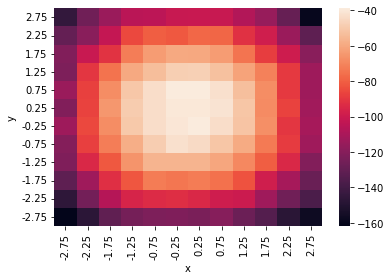

In [7]:
rl_squared_heatmap = heatmap(rl_squared_results, x_positions, y_positions,  0.5)
sns.heatmap(rl_squared_heatmap)

<Axes: xlabel='x', ylabel='y'>

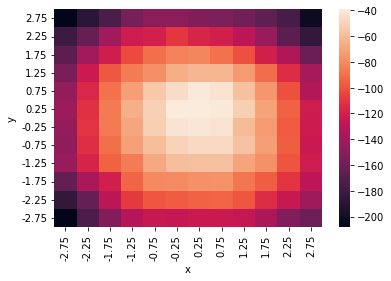

In [8]:
auto_dr_heatmap = heatmap(auto_dr_results, x_positions, y_positions,  0.5)
sns.heatmap(auto_dr_heatmap)

In [11]:
rl_squared_heatmap

x,-2.75,-2.25,-1.75,-1.25,-0.75,-0.25,0.25,0.75,1.25,1.75,2.25,2.75
y,,,,,,,,,,,,
2.75,-145.021420,-126.429538,-114.635592,-105.184900,-104.838989,-101.583303,-101.207698,-101.259982,-107.482093,-115.356618,-129.272748,-159.442034
2.25,-129.697287,-119.068121,-102.332658,-85.538139,-80.246912,-81.585281,-78.156273,-78.625998,-91.779740,-98.560360,-114.309548,-131.873221
1.75,-121.746623,-100.979075,-91.245070,-72.383523,-63.539235,-59.921782,-60.287000,-63.765024,-74.642721,-88.367232,-99.753859,-119.444668
1.25,-122.490403,-90.428660,-75.328198,-59.678037,-53.280384,-48.095785,-47.831554,-52.349016,-61.701092,-71.048660,-89.349846,-113.401418
0.75,-114.442897,-87.540700,-67.920694,-50.847976,-43.364050,-39.034667,-38.887622,-42.282855,-53.197515,-68.132551,-89.667423,-113.540662
0.25,-121.601535,-87.228304,-65.264271,-49.113591,-43.502080,-39.857728,-39.899863,-41.496539,-50.942749,-68.161952,-87.138078,-112.293941
-0.25,-113.377529,-85.656473,-67.976206,-50.346328,-43.489301,-40.591398,-39.341189,-43.641798,-51.473258,-67.356742,-90.223821,-111.179054
-0.75,-120.876144,-88.069047,-72.054326,-58.346884,-48.653543,-42.468048,-44.210676,-50.996204,-59.107217,-73.411584,-89.070026,-112.772006
-1.25,-121.990417,-94.984816,-81.621688,-66.037338,-56.253647,-56.263827,-56.186945,-60.505941,-69.165631,-80.177364,-94.707669,-121.134352


In [12]:
auto_dr_heatmap

x,-2.75,-2.25,-1.75,-1.25,-0.75,-0.25,0.25,0.75,1.25,1.75,2.25,2.75
y,,,,,,,,,,,,
2.75,-207.030540,-188.411744,-174.497025,-157.050306,-148.183876,-149.254075,-152.735721,-154.586842,-158.892262,-166.201816,-175.929793,-202.478349
2.25,-181.546734,-163.694298,-140.174339,-122.578971,-120.005569,-110.410576,-117.587785,-120.571398,-129.823911,-143.655656,-167.319655,-185.066747
1.75,-167.212483,-140.403230,-121.611931,-103.160636,-90.044053,-84.054266,-82.114447,-89.767124,-100.656673,-120.395780,-135.135366,-162.395871
1.25,-156.505195,-123.842026,-98.315161,-85.473354,-78.599095,-66.017473,-62.607558,-62.898339,-73.649634,-91.072607,-113.866300,-138.457091
0.75,-145.548157,-116.407289,-89.694736,-72.696836,-54.519792,-46.399885,-40.261736,-43.496448,-58.088190,-75.929724,-100.670765,-133.880501
0.25,-142.318968,-112.263293,-86.422193,-65.471487,-51.362261,-39.283822,-39.830170,-41.186714,-52.406783,-70.910501,-94.926898,-122.427943
-0.25,-145.033408,-111.294779,-86.387460,-69.240222,-52.291114,-42.654450,-41.330281,-43.455540,-60.860641,-74.158228,-97.318975,-123.457059
-0.75,-147.043734,-113.194942,-90.485993,-72.184824,-59.443799,-49.905786,-47.294090,-47.210910,-57.236460,-72.623780,-96.128202,-124.517492
-1.25,-143.727353,-118.335328,-94.807469,-85.438994,-68.908803,-59.443031,-58.945370,-58.584867,-70.245273,-78.162535,-99.437629,-122.721048
